In [215]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot

In [114]:
# Give shared_cell_type label to both adata objects 

In [115]:
shared_cell_type_table = pd.read_csv('data/tabula_cell_type_table.csv',index_col=0)

In [116]:
shared_cell_type_table.head()

,shared_cell_type,mouse_cell_types,human_cell_types
0,T cell,"['naive T cell', 'T cell', 'CD8-positive, alph...","['CD4-positive, alpha-beta T cell', 'naive thy..."
1,B cell,"['precursor B cell', 'immature B cell', 'naive...",['B cell']
2,NK cell,['natural killer cell'],['natural killer cell']
3,mast cell,['mast cell'],['mast cell']
4,erythrocyte,['erythrocyte'],['erythrocyte']


In [117]:
def label_uniform_cell_type_row(adata, shared_cell_type_table, species='human'):
    species_cell_types = adata.obs['cell_type']
    shared_cell_type_list = []
    for i in range(len(species_cell_types)):
        species_cell_type = species_cell_types.iloc[i]
        shared_cell_type = None
        for idx, row in shared_cell_type_table.iterrows():
            if species_cell_type in row[species+'_cell_types']:
                shared_cell_type = row['shared_cell_type']
        shared_cell_type_list.append(shared_cell_type)
    return shared_cell_type_list

In [91]:
shared_cell_types_human = label_uniform_cell_type_row(all_humans_adata, shared_cell_type_table, species='human')
all_humans_adata['shared_cell_type'] = shared_cell_types_human

['fibroblast',
 None,
 None,
 None,
 None,
 'thymocyte',
 'mast cell',
 None,
 'microglial cell',
 'myocyte',
 None,
 None,
 'T cell',
 'macrophage',
 None,
 None,
 'endothelial cell',
 None,
 None,
 None,
 'T cell',
 None,
 'neutrophil',
 'endothelial cell',
 None,
 'myocyte',
 'mesenchymal stem cell',
 None,
 'dendritic cell',
 'dendritic cell',
 'T cell',
 'fibroblast',
 None,
 'neutrophil',
 'fibroblast',
 'endothelial cell',
 None,
 None,
 'fibroblast',
 None,
 None,
 'pancreatic acinar cell',
 None,
 'monocyte',
 'neuron',
 None,
 'pancreatic beta cell',
 'thymocyte',
 None,
 None,
 None,
 None,
 'T cell',
 None,
 None,
 None,
 None,
 'myocyte',
 'endothelial cell',
 None,
 'pericyte',
 'smooth muscle cell',
 None,
 None,
 None,
 'pancreatic acinar cell',
 None,
 None,
 'myocyte',
 None,
 'neutrophil',
 None,
 'erythrocyte',
 None,
 'endothelial cell',
 'endothelial cell',
 None,
 None,
 'T cell',
 None,
 'pancreatic acinar cell',
 'T cell',
 None,
 None,
 'monocyte',
 None,
 Non

In [51]:
x = sc.pp.sample(all_humans_adata, n=100)

In [53]:
all_humans_adata

AnnData object with n_obs × n_vars = 100 × 61759
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_compartment', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'devel

In [32]:
all_humans_adata.obs['cell_type'].iloc[5]

'B cell'

## 1. Set up human and mouse adata objects

In [118]:
# Generate 100 point samples of equal cell type label balance from 4 humans with best representation
human_dir = 'data/tabula_sapiens/'
all_humans_adata = sc.read_h5ad(human_dir+'sampled_human_1000.h5ad')

In [119]:
shared_cell_types_human = label_uniform_cell_type_row(all_humans_adata, shared_cell_type_table, species='human')

In [120]:
all_humans_adata.obs['shared_cell_type'] = shared_cell_types_human

In [121]:
human_shared_cell_types_adata = all_humans_adata[all_humans_adata.obs['shared_cell_type'].notnull()]

In [122]:
human_shared_cell_types_adata.write_h5ad(human_dir+'sampled_human_shared.h5ad')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


#### 6 human adata objects

In [166]:
top_humans = all_humans_adata.obs['donor_id'].value_counts().index[:6].tolist()

In [167]:
human_adata = human_shared_cell_types_adata
human_adatas = []
human_donor_shared_cell_types = set(human_adata.obs['shared_cell_type'].unique().tolist())
for human in top_humans:
    this_human_adata = human_adata[human_adata.obs['donor_id']==human]
    human_adatas.append(this_human_adata)
    human_donor_shared_cell_types = human_donor_shared_cell_types.intersection(set(this_human_adata.obs['shared_cell_type'].unique().tolist()))
    #df.groupby('Category', group_keys=False).apply(lambda x: x.sample(frac=0.5, random_state=42))

#### 6 mouse adata objects

In [123]:
# Generate 100 point samples of equal cell type label balance from 4 mouse with best representation
mouse_dir = 'data/tabula_muris/'
all_mice_adata = sc.read_h5ad(mouse_dir+'sampled_mouse_1000.h5ad')

In [124]:
shared_cell_types_mouse = label_uniform_cell_type_row(all_mice_adata, shared_cell_type_table, species='mouse')

NameError: name 'all_mouse_adata' is not defined

In [126]:
all_mice_adata.obs['shared_cell_type'] = shared_cell_types_mouse
mouse_shared_cell_types_adata = all_mice_adata[all_mice_adata.obs['shared_cell_type'].notnull()]
mouse_shared_cell_types_adata.write_h5ad(mouse_dir+'sampled_mouse_shared.h5ad')

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [142]:
top_mice = all_mice_adata.obs['donor_id'].value_counts().index[:6].tolist()

In [143]:
mouse_adata = mouse_shared_cell_types_adata
mouse_adatas = []
mouse_donor_shared_cell_types = set(mouse_adata.obs['shared_cell_type'].unique().tolist())
for mouse in top_mice:
    this_mouse_adata = mouse_adata[mouse_adata.obs['donor_id']==mouse]
    mouse_adatas.append(this_mouse_adata)
    mouse_donor_shared_cell_types = mouse_donor_shared_cell_types.intersection(set(this_mouse_adata.obs['shared_cell_type'].unique().tolist()))

In [146]:
donor_shared_cell_types = mouse_donor_shared_cell_types & human_donor_shared_cell_types

#### subset to only shared cell types and sample to 100 cells per donor

In [453]:
min_cell_count = 40

In [454]:
# cell types with at least 10 cells from each donor
universal_cell_types = donor_shared_cell_types

for i in range(len(human_adatas)):
    cell_type_vc = human_adatas[i].obs['shared_cell_type'].value_counts()
    greater_than_10 = cell_type_vc[cell_type_vc>=min_cell_count].index.tolist()
    universal_cell_types = universal_cell_types.intersection(greater_than_10)
    
for i in range(len(mouse_adatas)):
    cell_type_vc = mouse_adatas[i].obs['shared_cell_type'].value_counts()
    greater_than_10 = cell_type_vc[cell_type_vc>=min_cell_count].index.tolist()
    universal_cell_types = universal_cell_types.intersection(greater_than_10)
    
universal_cell_types  

{'T cell', 'endothelial cell', 'macrophage', 'monocyte', 'smooth muscle cell'}

In [455]:
human_70_adatas = []
for human_adata in human_adatas:
    human_adata.obs['usable_cell_type'] = human_adata.obs['shared_cell_type'].apply(lambda x: x in universal_cell_types)
    human_usable_adata = human_adata[human_adata.obs['usable_cell_type']]
    human_70_indices = human_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
    human_70_adata = human_usable_adata[human_70_indices]
    human_70_adatas.append(human_70_adata)

/tmp/ipykernel_3631831/4071332395.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  human_70_indices = human_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
/tmp/ipykernel_3631831/4071332395.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  human_70_indices = human_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
/tmp/ipykernel_3631831/4071332395.py

In [460]:
human_70_adatas[0].obs['shared_cell_type'].value_counts()

shared_cell_type
T cell                40
endothelial cell      40
macrophage            40
monocyte              40
smooth muscle cell    40
Name: count, dtype: int64

In [456]:
mouse_70_adatas = []
for mouse_adata in mouse_adatas:
    mouse_adata.obs['usable_cell_type'] = mouse_adata.obs['shared_cell_type'].apply(lambda x: x in universal_cell_types)
    mouse_usable_adata = mouse_adata[mouse_adata.obs['usable_cell_type']]
    mouse_70_indices = mouse_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
    mouse_70_adata = mouse_usable_adata[mouse_70_indices]
    mouse_70_adatas.append(mouse_70_adata)

/tmp/ipykernel_3631831/1159759455.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mouse_70_indices = mouse_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
/tmp/ipykernel_3631831/1159759455.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mouse_70_indices = mouse_usable_adata.obs.groupby('shared_cell_type', group_keys=False).apply(lambda x: x.sample(n=min_cell_count, random_state=42)).index
/tmp/ipykernel_3631831/1159759455.py

In [461]:
mouse_70_adatas[0].obs['shared_cell_type'].value_counts()

shared_cell_type
T cell                40
endothelial cell      40
macrophage            40
monocyte              40
smooth muscle cell    40
Name: count, dtype: int64

### Set up OT

In [462]:
n_samples = min_cell_count*len(universal_cell_types)

In [480]:

def run_ot(d1, d2, n_samples):
    xs = d1.obsm['X_pca']
    xt = d2.obsm['X_pca']
    C1 = sp.spatial.distance.cdist(xs, xs)
    C2 = sp.spatial.distance.cdist(xt, xt)

    C1 /= C1.max()
    C2 /= C2.max()
    
    p = ot.unif(n_samples)
    q = ot.unif(n_samples)
    
    # Proximal Point algorithm with Kullback-Leibler as proximal operator
    gw, log = ot.gromov.entropic_gromov_wasserstein(
    C1, C2, p, q, "square_loss", epsilon=5e-4, solver="PPA", log=True)
    
    return log["gw_dist"], gw

In [230]:
pairs = [(0,1),(2,3),(4,5)]
human_dists = []
mouse_dists = []
for pair in pairs:
    human_dists.append(run_ot(human_70_adatas[pair[0]], human_70_adatas[pair[1]])[0])
    mouse_dists.append(run_ot(mouse_70_adatas[pair[0]], mouse_70_adatas[pair[1]])[0])

In [226]:
inter_dists = []
for i in range(6):
    inter_dists.append(run_ot(mouse_70_adatas[i], human_70_adatas[i])[0])

In [227]:
human_dists

[np.float64(0.015780303577603516),
 np.float64(0.018288665703156747),
 np.float64(0.01446198275436867)]

In [231]:
mouse_dists

[np.float64(0.033909099983805105),
 np.float64(0.024405178038787934),
 np.float64(0.02162763435049719)]

In [229]:
inter_dists

[np.float64(0.032440104450557825),
 np.float64(0.025516857200025368),
 np.float64(0.017285933307210108),
 np.float64(0.025862141469655254),
 np.float64(0.02342623619888614),
 np.float64(0.017128878527932847)]

In [282]:
adata1 = mouse_70_adatas[4]
adata2 = mouse_70_adatas[5]

In [283]:
d, gw = run_ot(adata1, adata2)

In [284]:
argmax_arr = np.argmax(gw, axis=1)

In [285]:
adata1_labels = adata1.obs['shared_cell_type'].tolist()

In [286]:
adata2_labels = adata2.obs['shared_cell_type'].iloc[argmax_arr].tolist()

In [287]:
matches = 0
match_pairs = []
for i in range(len(adata1_labels)):
    match_pairs.append((adata1_labels[i], adata2_labels[i]))
    if adata1_labels[i] == adata2_labels[i]:
        matches += 1
        
print(100*matches/70, '%, compared to random', 1/7)

32.857142857142854 %, compared to random 0.14285714285714285


In [288]:
match_pairs

[('NK cell', 'fibroblast'),
 ('NK cell', 'fibroblast'),
 ('NK cell', 'fibroblast'),
 ('NK cell', 'NK cell'),
 ('NK cell', 'T cell'),
 ('NK cell', 'fibroblast'),
 ('NK cell', 'fibroblast'),
 ('NK cell', 'NK cell'),
 ('NK cell', 'NK cell'),
 ('NK cell', 'fibroblast'),
 ('T cell', 'NK cell'),
 ('T cell', 'macrophage'),
 ('T cell', 'NK cell'),
 ('T cell', 'macrophage'),
 ('T cell', 'T cell'),
 ('T cell', 'macrophage'),
 ('T cell', 'T cell'),
 ('T cell', 'macrophage'),
 ('T cell', 'T cell'),
 ('T cell', 'T cell'),
 ('endothelial cell', 'endothelial cell'),
 ('endothelial cell', 'fibroblast'),
 ('endothelial cell', 'endothelial cell'),
 ('endothelial cell', 'endothelial cell'),
 ('endothelial cell', 'NK cell'),
 ('endothelial cell', 'fibroblast'),
 ('endothelial cell', 'endothelial cell'),
 ('endothelial cell', 'smooth muscle cell'),
 ('endothelial cell', 'NK cell'),
 ('endothelial cell', 'endothelial cell'),
 ('fibroblast', 'smooth muscle cell'),
 ('fibroblast', 'smooth muscle cell'),
 ('fi

In [482]:
def ot_between_organisms(adata1, adata2, n_samples):
    d, gw = run_ot(adata1, adata2, n_samples)
    argmax_arr = np.argmax(gw, axis=1)
    adata1_labels = adata1.obs['shared_cell_type'].tolist()
    adata2_labels = adata2.obs['shared_cell_type'].iloc[argmax_arr].tolist()
    
    matches = 0
    match_pairs = []
    for i in range(len(adata1_labels)):
        match_pairs.append((adata1_labels[i], adata2_labels[i]))
        if adata1_labels[i] == adata2_labels[i]:
            matches += 1
            
    matching_accuracy = 100*matches/adata1.n_obs
    
    #print(matching_accuracy, '%, compared to random', 1/7, '%')
    #print(match_pairs)
    
    return matching_accuracy, match_pairs

In [366]:
pairs = [(0,1),(2,3),(4,5)]
for pair in pairs:
    acc, pairings = ot_between_organisms(mouse_70_adatas[pair[0]], mouse_70_adatas[pair[1]])
    print(pair, acc, '%')

(0, 1) 55.5 %
(2, 3) 65.5 %
(4, 5) 50.5 %


In [367]:
pairs = [(0,1),(2,3),(4,5)]
for pair in pairs:
    acc, pairings = ot_between_organisms(human_70_adatas[pair[0]], human_70_adatas[pair[1]])
    print(pair, acc, '%')

(0, 1) 13.5 %
(2, 3) 42.5 %
(4, 5) 48.5 %


In [368]:
for i in range(6):
    acc, pairings = ot_between_organisms(mouse_70_adatas[i], human_70_adatas[i])
    print(i, acc, '%')

0 6.0 %
1 46.5 %
2 10.0 %
3 7.0 %
4 14.5 %
5 2.0 %


In [ ]:
pairings

In [388]:
(x=='T cell').idxmax()

'ATCGAGTGTTGAGTTC-1-0-1-0'

In [394]:
x[x.index.tolist()[:5]]

index
AAGACCTAGTCTCCTC-1-57-1-0      monocyte
CTACCCACACGAAACG-1-57-1-0      monocyte
TACTCGCTCATGCATG-1-57-1-0      monocyte
CCTCAGTGTGTAATGA-1-57-1-0    macrophage
TGCACCTGTTGGTGGA-1-50-1-0       NK cell
Name: shared_cell_type, dtype: category
Categories (7, object): ['NK cell', 'T cell', 'endothelial cell', 'fibroblast', 'macrophage', 'monocyte', 'smooth muscle cell']

In [393]:
x.index.tolist()[:5]

['AAGACCTAGTCTCCTC-1-57-1-0',
 'CTACCCACACGAAACG-1-57-1-0',
 'TACTCGCTCATGCATG-1-57-1-0',
 'CCTCAGTGTGTAATGA-1-57-1-0',
 'TGCACCTGTTGGTGGA-1-50-1-0']

In [374]:
x = adata1.obs['shared_cell_type'].sample(frac=1)

In [433]:
mouse_70_adatas[0].obs['shared_cell_type']['TGGCCAGGTAGAGGAA-1-3-1-0']

'smooth muscle cell'

In [474]:
def sample_equal_cell_types(adata1, adata2, sample_size):
    cell_series_1 = adata1.obs['shared_cell_type'].sample(frac=1)
    cell_series_2 = adata2.obs['shared_cell_type'].sample(frac=1)
    
    index_list_1 = []
    index_list_2 = []
    
    i = 0
    while len(index_list_1) < sample_size:
        idx = cell_series_1.index[i]
        shared_cell_type = cell_series_1[idx]
        first_paired_idx = (cell_series_2 == shared_cell_type).idxmax()
        if first_paired_idx:
            index_list_1.append(idx)
            index_list_2.append(first_paired_idx)
        cell_series_2[first_paired_idx] = None
        i += 1 
        
        
    return adata1[index_list_1], adata2[index_list_2]

In [475]:
a, b = sample_equal_cell_types(human_70_adatas[0], mouse_70_adatas[0], 100)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (70,) and arg 1 with shape (4,).

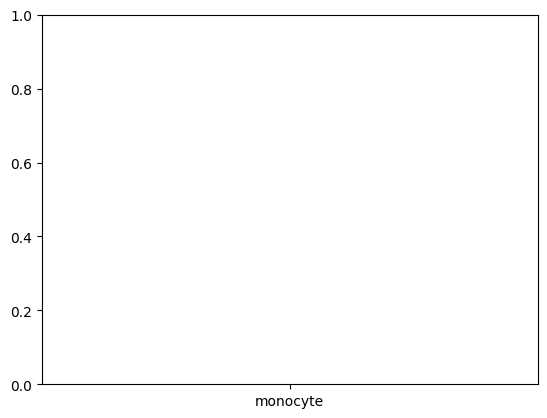

In [483]:
mouse_variable_adatas = []
accs = []
mouse_cell_counts = [50, 100, 200, 300]
for sample_size in mouse_cell_counts:
    mouse_var_adata1, mouse_var_adata2 = sample_equal_cell_types(mouse_adatas[0], mouse_adatas[1], sample_size)
    acc, pairings = ot_between_organisms(mouse_var_adata1, mouse_var_adata2, sample_size)
    accs.append(acc)
    
plt.bar(x, accs)



In [484]:
accs

[70.0, 59.0, 38.5, 25.666666666666668]